In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import js
import pickle
import random
import numpy as np





In [7]:
mdf=pd.read_pickle('F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC=0.1_minN=50.pandas.df.pickle')
mdf.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(108, 73, 21)",1.030567e-46,4.429628,8.385350,3.208155e-43
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(162, 108, 42)",2.617632e-66,4.301851,7.889255,8.148688e-63
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(107, 85, 25)",6.657682e-42,4.085253,7.098879,2.072536e-38
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(105, 80, 29)",6.524524e-41,4.065093,7.029848,2.031084e-37


In [8]:
allmdf=pd.read_pickle('F05-Syntax-Features/2-all-phrases-possible-withRealData-50k.pd.df.pickle')
allmdf=allmdf.loc[allmdf['phrase-type']=='parse_ord_ori_spc',:]
allmdf['phrase-key']=allmdf.phrase.apply(lambda pi: '_'.join([str(i) for i in pi]))
allmdf=allmdf.set_index('phrase-key')
allmdf.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
phrase-key,,,,,
E_24_E,"(E, 24, E)",parse_ord_ori_spc,2,True,"(297, 1183, 669)"
E_56_g,"(E, 56, g)",parse_ord_ori_spc,2,True,"(642, 2224, 1402)"
g_33_G,"(g, 33, G)",parse_ord_ori_spc,2,True,"(356, 1601, 921)"
G_24_G,"(G, 24, G)",parse_ord_ori_spc,2,True,"(776, 4788, 3197)"
g_22_G,"(g, 22, G)",parse_ord_ori_spc,2,True,"(2170, 8041, 4725)"


In [9]:
E35G=allmdf.at['E_35_G','real-data']
g10E=mdf.at['ord_ori_spc=g_10_E','real-data']
g10E35G=mdf.at['ord_ori_spc=g_10_E_35_G','real-data']
E35G,g10E

((2257, 10549, 5942), (5871, 17931, 9798))

8199 2257 0.2752774728625442
15669 5871 0.3746888761248325
434 233 0.5368663594470046


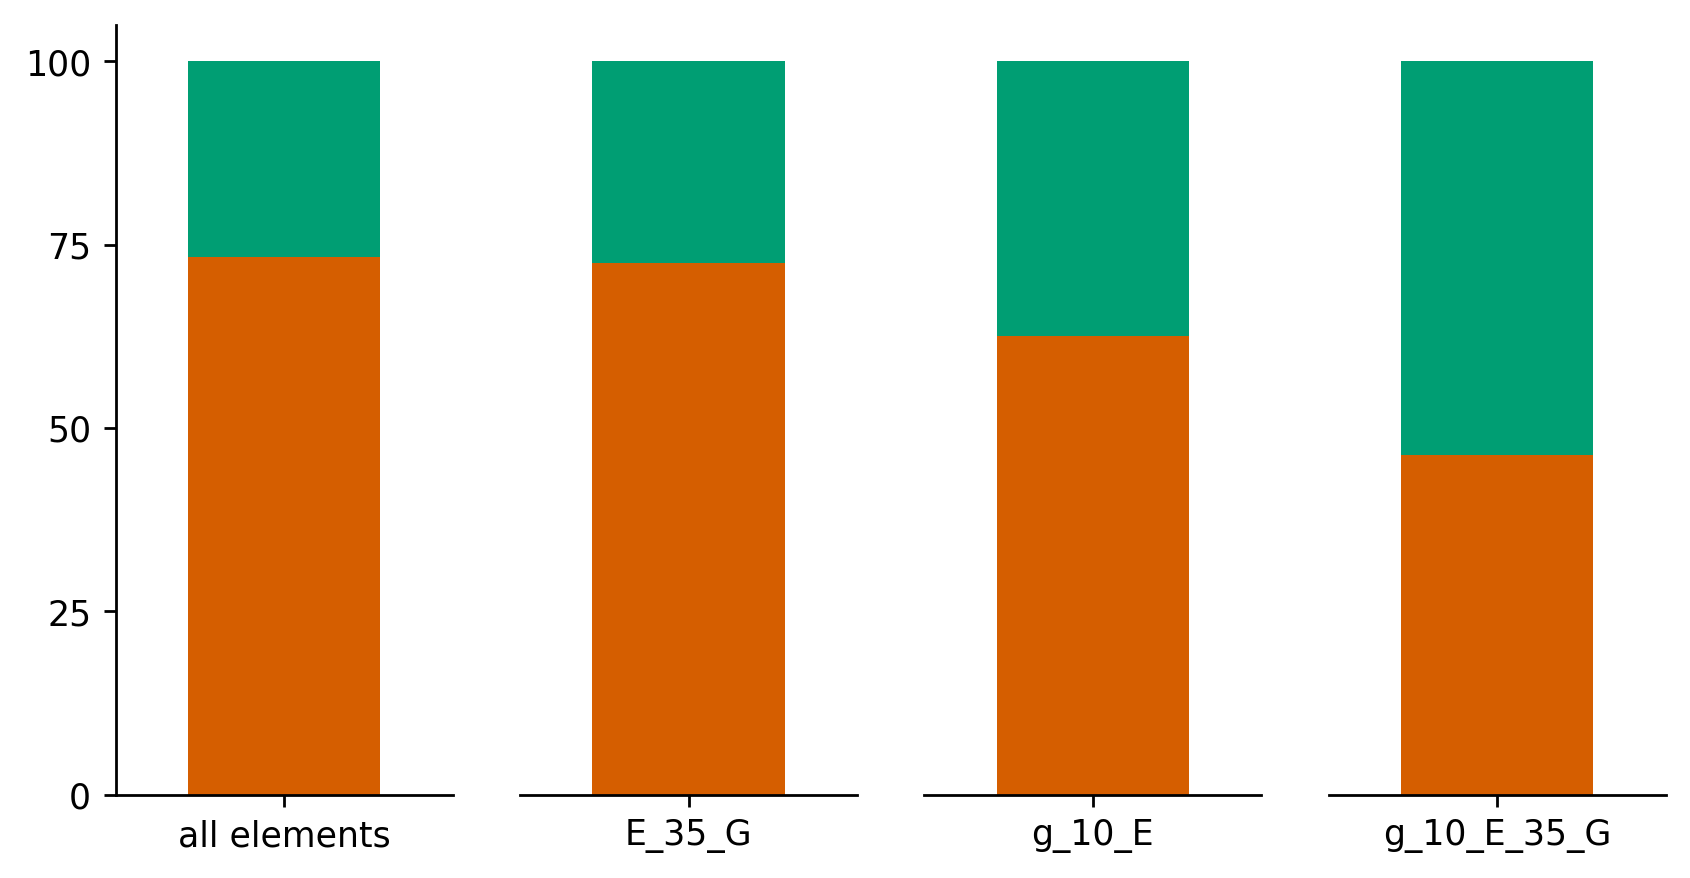

In [12]:
numFuncDepGE=52_139
numInert=143_799
n=numFuncDepGE+numInert

fig,ax=plt.subplots(1,4,figsize=(8,4),dpi=250)
xticklabels=[]

# null
xticklabels.append("Null")
ax[0].bar(0,height=100*numInert/n                      ,color=js.cb['red'])
ax[0].bar(0,height=100*numFuncDepGE/n,bottom=100*numInert/n,color=js.cb['green'])

# motifs
for axi,label,data in [(1,'E_35_G',E35G),(2,'g_10_E',g10E),(3,'g_10_E_35_G',g10E35G)]:

    funcGE,_,inert=data
    tot=funcGE+inert
    
    print(tot,funcGE,funcGE/tot,)
    
    pa=100*funcGE/tot
    pi=100*inert/tot
    
    xticklabels.append(label)
    
    ax[axi].bar(0,height=pi                          ,color=js.cb['red'])
    ax[axi].bar(0,height=pa,bottom=pi    ,color=js.cb['green'])
    # ax[axi].bar(0,height=inert /tot                          ,color=js.cb['red'])
    # ax[axi].bar(0,height=funcGE/tot,bottom=inert /tot    ,color=js.cb['lightblue'])

# ax[0].set_ylabel('Associated Inert vs Active Enhancers [%]')
xlims=.7
for i,xlab in [(0,'all elements'),(1,'E_35_G'),(2,'g_10_E'),(3,'g_10_E_35_G')]:
    ax[i].set_xlim(-xlims,xlims)
    js.clearspines(ax[i])
    js.clearticks(ax[i],sides=['x'])
    ax[i].set_xticks([0],labels=[xlab])
    # ax[i].set_xticklabels([xticklabels[i]])
    ax[i].set_yticks([0,25,50,75,100],labels=[0,25,50,75,100])
    
for i in [1,2,3]:
    js.clearspines(ax[i],sides=['left'])
    js.clearticks(ax[i],sides=['y'])
    
# out='000-manuscript-figs/06c_MOT_20230919_Enrichment-distribution-of-motifs__enrichment-barcharts.svg'
# plt.savefig(out,format='svg',transparent=True)